> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy numpy pandas


In [ ]:
# Fetch this case's data files when they are not already next to the notebook.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/Index_Tracking_Portfolio/'
FILES = [
    'index_sample.csv',
    'initial_sample.csv',
    'return_sample.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')

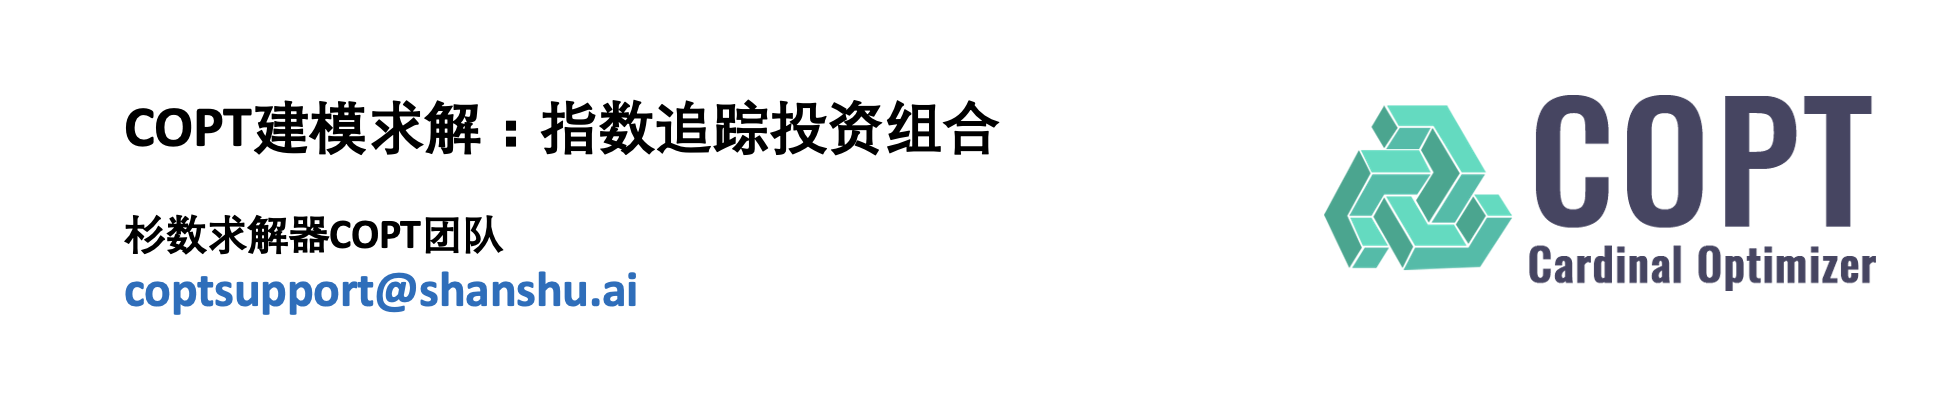

# 代码实现

## 建模求解MIQP问题步骤

在Python中调用COPT对MIQP问题进行建模和求解的基本步骤如下：

1. 导入 `coptpy` 包

2. 添加/导入模型测试**数据**

3. 创建**求解环境**和求解**模型**

4. 构建模型，依次添加**模型三要素**
    - 添加**决策变量**：整数型（或0-1型）以及连续型
    - 设置**二次目标函数**
    - 添加**约束条件**


5. **求解**

6. 查看和分析求解**结果**

## 添加测试数据和参数
这里选用了2020年底到2023年底期间S&P500指数和S&P500中权重最大的前50支股票的收益率数据。

**1. 添加股票池内的股票列表和在此时间周期内对应的收益率列表**

In [1]:
import pandas as pd
import numpy as np
return_df = pd.read_csv('return_sample.csv')

# 将dataframe转化为便于建模的array形式
return_df_arr = np.array(return_df)

# 生成用于存储股票代号的array
STOCK_arr = np.array(return_df.columns)

**2. 输入S&P500指数在此时间周期内的收益率**

In [3]:
index_df = pd.read_csv('index_sample.csv')

# 将dataframe转化为便于建模的array形式
index_df_arr = np.array(index_df)

**3. 输入初始的股票选择的列表**

In [5]:
initial_df = pd.read_csv('initial_sample.csv')

# 将dataframe转化为便于建模的array形式
initial_df_arr = np.array(initial_df)

**4. 根据添加的股票数据，确认股票池中的股票数量**

In [10]:
NPERIOD = len(return_df_arr)
NSTOCK = len(STOCK_arr)
print(NSTOCK,NPERIOD)

50 36


**5. 输入自定义的模型参数**

In [13]:
# 设置投资组合中的股票数量为4支，可根据实际情况调节
NSELECT = 4

# 设置换手率为80%，可根据实际情况调节
TURNRATE = 0.8

# 设置投资组合中每支股票的最高占比，占比不能小于1/NSELECT，注意最高占比和TURNRATE的关系，避免不可行解的情况
UP_BOUND = 1

## 创建求解环境和求解模型

这是在Python中调用COPT建模和求解前必备的步骤：

In [16]:
import coptpy as cp
from coptpy import COPT 

# Create environment
env = cp.Envr()

# Create model 
model = env.createModel(name="index_tracking")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

1. 添加类型为 ``vtype=COPT.BINARY`` 的0-1变量 ``z`` ；
2. 添加类型为 ``vtype=COPT.CONTINUOUS`` 连续变量 ``w`` 和 ``dummy_abs`` 。


In [19]:
w = {}
z = {}
dummy_abs = {}
for i in range (NSTOCK):
    # 添加股票在投资组合内占比的决策参数，设置下限为0，上限为UP_BOUND
    w[i] = model.addVar(lb = 0, ub = UP_BOUND, vtype = COPT.CONTINUOUS)
    # 添加股票是否被选择的决策参数
    z[i] = model.addVar(vtype = COPT.BINARY)
    # 添加辅助变量用于绝对值约束的建模
    dummy_abs[i] = model.addVar(vtype = COPT.CONTINUOUS)

### 设置目标函数

目标函数为追踪误差，由多个周期内所选投资组合的预期回报率和市场回报率误差的平方构成，``sense`` 指定优化方向为``COPT.MINIMIZE`` 。

$$
Minimize \sum_{t \in NPERIOD} (\sum_{i \in STOCK} return_{t,i}\cdot w_i-return_{t,sp})^2 / NPERIOD 
$$

In [23]:
obj = cp.quicksum((cp.quicksum(return_df_arr[t][i] * w[i] for i in range(NSTOCK)) - index_df_arr[t][0]) ** 2 for t in range(NPERIOD))/ NPERIOD
model.setObjective(obj, COPT.MINIMIZE)

<font color=#0000FF>
<b>提示：推荐使用quicksum()</b>
</font>   

这里我们用到COPT中的辅助函数quicksum()实现加和运算。虽然和Python中的内置函数sum()实现的功能一致，但是使用quicksum()的性能更好，它对求和过程进行了优化，因此速度更快、占用内存空间更少，比调用sum()（或直接使用加号运算符）性能上会好很多，特别针对大规模问题建模时。


### 添加约束条件

**1. 构成投资组合的所有股票占比总和为1：**

$$
\sum_{i \in STOCK} w_i = 1
$$

In [28]:
model.addConstr(cp.quicksum(w[i] for i in range(NSTOCK)) == 1, name="budget")

<coptpy.Constraint: budget>

**2. 构成投资组合中股票的数量不超过NSELECT：**

$$
\sum_{i \in STOCK} z_i \leq NSELECT
$$

In [31]:
model.addConstr(cp.quicksum(z[i] for i in range(NSTOCK)) <= NSELECT, name="cardinality")

<coptpy.Constraint: cardinality>

**3. 如果股票i未被选择 ($z_i=0$) ，则股票i在投资组合中的占比为0 ($w_i=0$) ：**

$$
w_i \le z_i, \hspace{1cm} \forall i \in STOCK
$$

In [34]:
model.addConstrs((w[i] <= z[i] for i in range(NSTOCK)), nameprefix="indicator")

<font color=#0000FF>
<b>提示：另一种建模方式 —— indicator约束</b>
</font>   

Indicator约束是一类 **If-Then** 逻辑关系约束，它以一个 **二进制类型变量** $y$ 作为Indicator变量，根据变量 $y$ 的取值，决定 **线性约束** $a^{T}x \leq b$ 是否成立：

$$
\begin{align}
y &= f \rightarrow a^{T}x \leq b\\
f &\in \{0, 1\}
\end{align}
$$

即表示：如果 y = f, 那么线性约束成立。

对于If-Then形式的条件约束，可以使用COPT中的Indicator约束构建器 ``Model.addGenConstrIndicator() `` 进行添加。指定如下参数：

- ``binVar`` ：二进制类型的变量作为Indicator

- ``binval`` ：If条件中的Indicator变量的取值（0或1）

- ``builder`` ：Then结论中成立的线性约束表达式

代码实现如下：

```python
for i in range(NSTOCK):
    model.addGenConstrIndicator(z[i], 0, w[i] == 0)
```

**4. 投资组合的月平均回报率需不少于市场的月平均回报率：**

$$
\frac{(\sum_{t \in NPERIOD}(\sum_{i \in STOCK} return_{t,i}\cdot w_i))}{NPERIOD} \ge \frac{(\sum_{t \in NPERIOD}return_{t,sp})}{NPERIOD}
$$

In [38]:
model.addConstr(cp.quicksum(cp.quicksum(return_df_arr[t][i] * w[i] for i in range(NSTOCK)) for t in range(NPERIOD)) >= \
                cp.quicksum(index_df_arr[t][0] for t in range(NPERIOD)), name="return_lb")

<coptpy.Constraint: return_lb>

**5. 考虑控制组合平衡成本，设置换手率上限，由于一支股票买进同时会对应另一支股票的卖出，我们需在更换股票的数量上除以2：**

$$
\sum_{i \in STOCK} \frac{|z_i - initial_i|}{2 \cdot NSELECT} \le TURNRATE  
$$

在Python中添加模型时，我们可以使用辅助变量*dummy_abs<sub>i</sub>* 将此约束转换为以下两个约束，并直接使用COPT中的绝对值约束构建器 ``Model.addGenConstrAbs() `` 进行添加。

$$
\begin{align}
dummy\_{abs}_i &= |z_i - initial_i|, \hspace{1cm} \forall i \in STOCK\\
\sum_{i \in STOCK} dummy\_abs_i &\le 2 \cdot TURNRATE \cdot NSELECT
\end{align}
$$


In [41]:
for i in range(NSTOCK):
    model.addGenConstrAbs(dummy_abs[i], z[i] - initial_df_arr[0][i], name="abs_def")
    
model.addConstr(cp.quicksum(dummy_abs[i] for i in range(NSTOCK)) <= 2 * NSELECT * TURNRATE, name="turnover")

<coptpy.Constraint: turnover>

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数进行求解。

In [44]:
model.solve()

Model fingerprint: d192f9a4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIQP problem

The original problem has:
    204 rows, 250 columns and 600 non-zero elements
    150 binaries
    100 indicators
    1275 quadratic objective elements

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    90 rows, 172 columns and 1504 non-zero elements
    50 binaries
    36 SOC rows and 108 non-zero elements

Problem info:
    Range of matrix coefficients:    [2e-06,2e+00]
    Range of rhs coefficients:       [4e-03,4e+00]
    Range of bound coefficients:     [2e-05,1e+00]
    Range of cost coefficients:      [2e-03,1e+00]
    Density of cost:                     50.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0   

最后，根据模型的求解结果，我们可以将选择的股票组合、以及相对于在投资组合中的份额、投资组合的预期回报率和指数追踪的误差打印出来：

In [46]:
if model.status == COPT.OPTIMAL:
    print("追踪误差: {:.12f}%".format(model.objval))    
    optimal_return = sum(w[i].x  *  sum(return_df_arr[t][i] for t in range(NPERIOD))/NPERIOD for i in range(NSTOCK))
    print("投资组合月回报率: {:.2f}%".format(optimal_return * 100))
    print("-" * 30)
    print("投资组合中的股票:")
    for i in range(NSTOCK):
        if w[i].x > 1e-10:
            print('股票{}: 投入{:.2f}%'.format(STOCK_arr[i], w[i].x * 100))

追踪误差: 0.000118708870%
投资组合月回报率: 0.79%
------------------------------
投资组合中的股票:
股票NVDA: 投入15.86%
股票JNJ: 投入40.95%
股票HD: 投入18.70%
股票DIS: 投入24.50%
